In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

# Global Plot Aesthetics: Dark Plasma Theme
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['grid.color'] = '#2b2b2b'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6

# Load processed data cleanly without warnings
df = pd.read_csv('../data/processed/uber_cleaned.csv', low_memory=False)
df['date'] = pd.to_datetime(df['date'])
# Fast hour extraction
df['time_hour'] = df['time'].astype(str).str.split(':').str[0].astype(int)

print(f"Dataset Loaded Cleanly: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset Loaded Cleanly: 150,000 rows, 20 columns


## 1.1 Marketplace Booking Fulfillment & Failure Breakdown

### 🎯 Objective

Evaluate overall platform fulfillment efficiency by analyzing the volume and share of completed trips versus various cancellation and failure modes.

### ❓ Business Question

What proportion of total ride demand is successfully fulfilled, and where is the primary operational leakage occurring across the marketplace funnel?

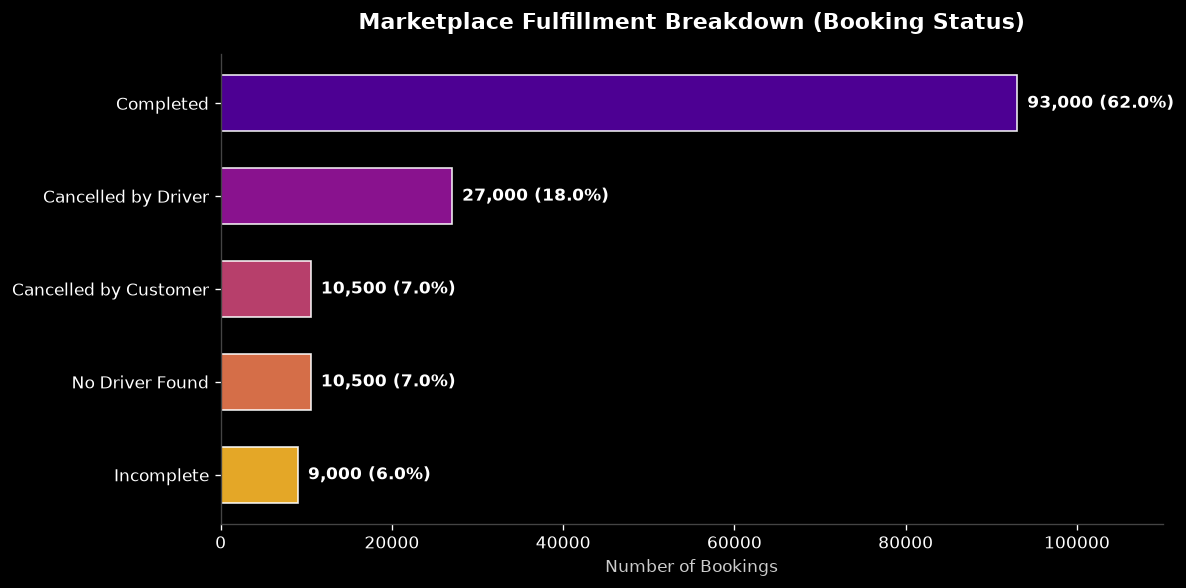

In [2]:
# 1. Target Value Counts
status_counts = df['booking_status'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

# Generate distinct Plasma colors for bars
plasma_colors = cm.plasma(np.linspace(0.15, 0.85, len(status_counts)))

bars = ax.barh(status_counts.index, status_counts.values, color=plasma_colors, edgecolor='#ffffff', alpha=0.9, height=0.6)

# Value & percentage labels
for bar in bars:
    width = bar.get_width()
    pct = width / len(df) * 100
    ax.text(width + 1200, bar.get_y() + bar.get_height()/2, 
            f'{int(width):,} ({pct:.1f}%)', 
            va='center', fontsize=10, fontweight='bold', color='#ffffff')

ax.set_title('Marketplace Fulfillment Breakdown (Booking Status)', fontsize=13, fontweight='bold', pad=15, color='#ffffff')
ax.set_xlabel('Number of Bookings', fontsize=10, color='#cccccc')
ax.set_xlim(0, 110000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 💡 Business Takeaway

The marketplace fulfillment analysis establishes baseline operational conversion efficiency, highlighting where top-of-funnel ride demand fails before completion and identifying the largest levers for revenue recovery.

### 💡 Business Insight

- Out of **150,000 total booking requests**, only **62.0% (93,000 rides)** are successfully completed, resulting in a **38.0% (57,000 rides) operational failure rate**.
- **Driver-initiated cancellations** form the single largest failure point, accounting for **18.0% (27,000 rides)** of all requests—more than customer cancellations and driver shortages combined.
- **Customer cancellations** and **No Driver Found** events each account for approximately **7.0% (10,500 rides)**, while **Incomplete Rides** represent **6.0% (9,000 rides)**.
- The high driver cancellation rate indicates that platform friction is concentrated primarily on driver acceptance and trip completion willingness rather than lack of passenger demand.

### 🚀 Recommendations

* **Show upfront trip fare and exact pickup distance to drivers** so they don't accept rides blindly and cancel later.
* **Give small bonus incentives for short pickups during rush hours** to motivate drivers to accept nearby rides quickly.
* **Auto-assign a backup driver if the initial driver takes too long to arrive**, preventing riders from getting frustrated and cancelling.
* **Track vehicle breakdowns and mid-trip drop-offs closely** to identify repeating car issues or bad routes.

## 1.2 Vehicle Tier Demand & Fulfillment Performance

### 🎯 Objective

Evaluate booking volume, gross revenue contribution, and fulfillment outcome distribution across different vehicle categories to identify key growth drivers and fleet vulnerabilities.

### ❓ Business Question

Which vehicle tiers drive the majority of platform demand, and do cancellation or failure patterns vary significantly across different vehicle types?

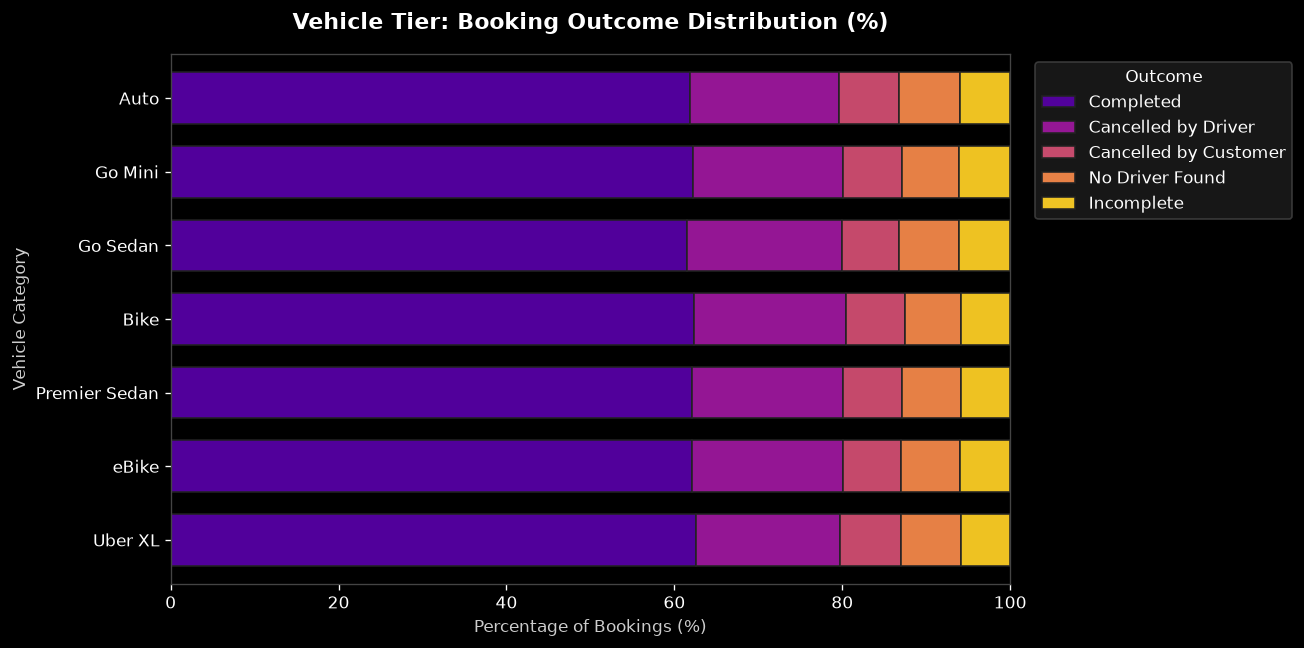

In [5]:
# Group by vehicle type and booking status (Percentage distribution)
veh_status = pd.crosstab(df['vehicle_type'], df['booking_status'], normalize='index') * 100

# Reorder columns logically
order_cols = ['Completed', 'Cancelled by Driver', 'Cancelled by Customer', 'No Driver Found', 'Incomplete']
veh_status = veh_status[[c for c in order_cols if c in veh_status.columns]]

# Sort by volume share
veh_order = df['vehicle_type'].value_counts().index
veh_status = veh_status.loc[veh_order]

# Plot Stacked Horizontal Bar with Plasma theme
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = cm.plasma(np.linspace(0.15, 0.9, len(veh_status.columns)))

veh_status.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='#222222', alpha=0.95, width=0.7)

ax.set_title('Vehicle Tier: Booking Outcome Distribution (%)', fontsize=13, fontweight='bold', pad=15, color='#ffffff')
ax.set_xlabel('Percentage of Bookings (%)', fontsize=10, color='#cccccc')
ax.set_ylabel('Vehicle Category', fontsize=10, color='#cccccc')
ax.set_xlim(0, 100)
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='#1e1e1e', edgecolor='#444444')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 💡 Business Takeaway

The vehicle tier performance analysis reveals the core operational pillars of the platform, showing that demand is concentrated in entry-level, cost-effective transit modes while fulfillment leakage remains systemic across all tiers.

### 💡 Business Insight

- **Auto** is the single largest demand driver, capturing **24.95% (37,419 bookings)** of total platform volume and contributing **₹12.88 million** in gross revenue.
- **Go Mini (19.87% / 29,806 bookings)** and **Go Sedan (18.09% / 27,141 bookings)** follow as secondary pillars, together generating over **₹19.70 million** in revenue.
- **Micro-mobility (Bike + eBike)** accounts for **22.05% (33,074 bookings)**, proving high urban consumer reliance on two-wheelers for daily commuting.
- **Outcome Distribution is Uniform:** Completion rates remain remarkably flat across all vehicle categories (**61.4% to 62.6%**), and driver cancellation rates consistently hover between **17.1% and 18.5%**, proving that failure is systemic across the network rather than vehicle-specific.

### 🚀 Recommendations

* **Focus driver hiring and daily bonuses on Auto and Go Mini** since these two categories drive nearly 45% of total platform bookings.
* **Promote Bike and eBike options during peak traffic hours** as a faster, cheaper alternative for single commuters trying to beat congestion.
* **Keep higher premium pricing on Uber XL and Premier Sedans** to protect profit margins on low-volume, high-value luxury trips.
* **Suggest Go Mini automatically when no Autos are nearby** so riders can book an available cab instead of leaving the app.

## 1.3 Temporal Demand Dynamics & Peak Rush Analysis

### 🎯 Objective

Analyze the 24-hour temporal distribution of booking requests to identify peak commute surges, off-peak troughs, and hourly fulfillment stability.

### ❓ Business Question

During which hours does the platform experience peak demand surges, and does fulfillment efficiency degrade under heavy rush-hour load?

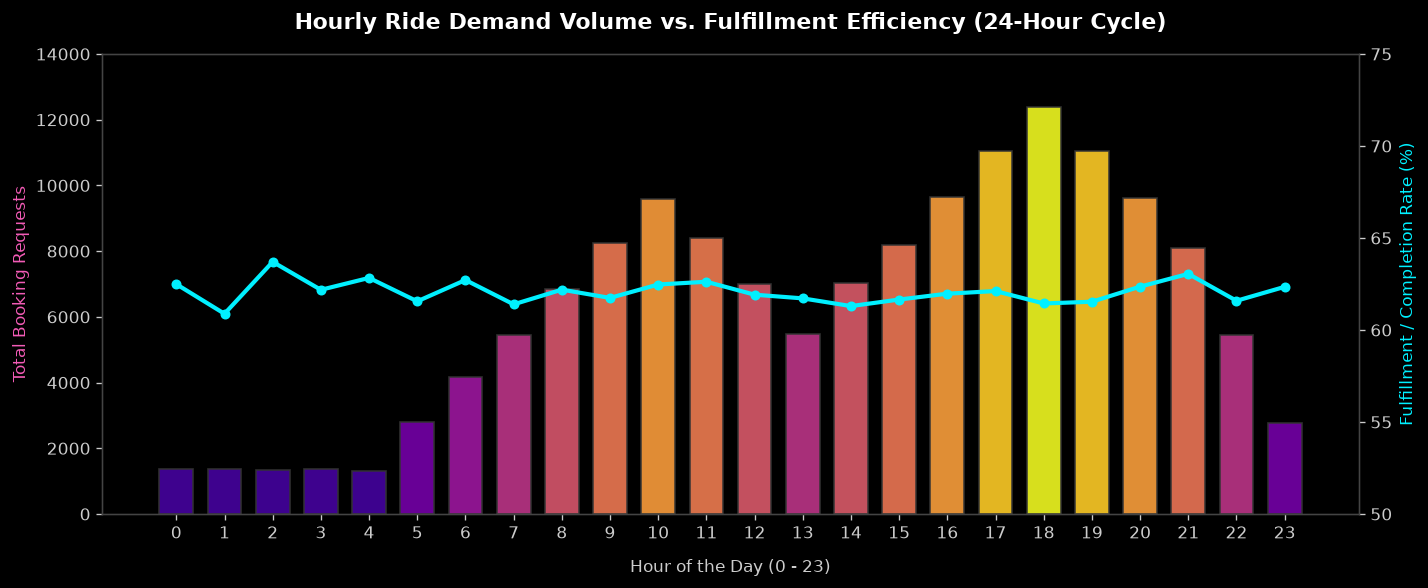

In [6]:
# 1. Hourly Aggregations
hourly_agg = df.groupby('time_hour').agg(
    total_demand=('booking_id', 'count'),
    completed=('booking_status', lambda x: (x == 'Completed').sum()),
    revenue=('booking_value', 'sum')
).reset_index()

hourly_agg['completion_rate'] = (hourly_agg['completed'] / hourly_agg['total_demand']) * 100

# 2. Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

# Primary Bar Chart (Total Demand with Plasma Gradient)
norm_vals = hourly_agg['total_demand'] / hourly_agg['total_demand'].max()
plasma_bar_colors = cm.plasma(norm_vals)

bars = ax1.bar(
    hourly_agg['time_hour'], 
    hourly_agg['total_demand'], 
    color=plasma_bar_colors, 
    edgecolor='#333333', 
    alpha=0.9, 
    width=0.7,
    label='Hourly Demand'
)

ax1.set_xlabel('Hour of the Day (0 - 23)', fontsize=10, color='#cccccc', labelpad=10)
ax1.set_ylabel('Total Booking Requests', fontsize=10, color='#f15bb5')
ax1.set_xticks(range(0, 24))
ax1.tick_params(colors='#cccccc')
ax1.set_ylim(0, 14000)

# Secondary Line Chart (Completion Rate %)
ax2 = ax1.twinx()
ax2.plot(
    hourly_agg['time_hour'], 
    hourly_agg['completion_rate'], 
    color='#00f0ff', 
    marker='o', 
    linewidth=2.5, 
    markersize=5,
    label='Completion Rate (%)'
)
ax2.set_ylabel('Fulfillment / Completion Rate (%)', fontsize=10, color='#00f0ff')
ax2.set_ylim(50, 75)
ax2.grid(False)
ax2.tick_params(colors='#cccccc')

# Title & Legend setup
plt.title('Hourly Ride Demand Volume vs. Fulfillment Efficiency (24-Hour Cycle)', fontsize=13, fontweight='bold', pad=15, color='#ffffff')
fig.tight_layout()
plt.show()

### 💡 Business Takeaway

The hourly temporal analysis identifies critical commuter surge windows, demonstrating when operational capacity is most stressed and where dynamic driver positioning can capture maximum revenue.

### 💡 Business Insight

- The marketplace exhibits a distinct **bimodal commute curve**, with a massive **Evening Peak (16:00 – 20:00)** and a secondary **Morning Rush (09:00 – 11:00)**.
- **6:00 PM (18:00)** is the highest demand hour across the network, generating **12,397 booking requests** and over **₹4.27 million** in gross revenue in a single hour window.
- The 4-hour evening window (**17:00 to 20:00**) accounts for **44,118 bookings (29.4% of daily volume)** and generates **₹15.17 million** in revenue.
- Off-peak troughs occur during the late night / early morning hours (**01:00 – 04:00**), where hourly demand drops to ~1,300 bookings.
- Fulfillment efficiency remains remarkably stable between **60.8% and 63.7%** across all 24 hours, indicating consistent baseline capacity rather than severe peak-hour network collapse.

### 🚀 Recommendations

* **Offer extra earning incentives to drivers between 4:30 PM and 7:30 PM** so enough vehicles are on the road right before the 6:00 PM peak rush.
* **Send app alerts to drivers in quieter areas 30 minutes before evening rush hour**, guiding them to move toward high-demand pickup spots.
* **Provide small afternoon discounts (12:00 PM to 3:00 PM)** to encourage non-urgent riders to book during slower hours and balance out demand.
* **Ensure enough Bikes and eBikes are available for late-night riders** to prevent booking drops when regular cab supply slows down.

## 1.4 Cancellation & Operational Failure Root-Cause Analysis

### 🎯 Objective

Diagnose the primary drivers behind non-completed rides by dissecting self-reported reasons for both driver-initiated and customer-initiated cancellations.

### ❓ Business Question

What are the predominant operational friction points causing drivers and customers to abort bookings, and how do their underlying motivations differ?

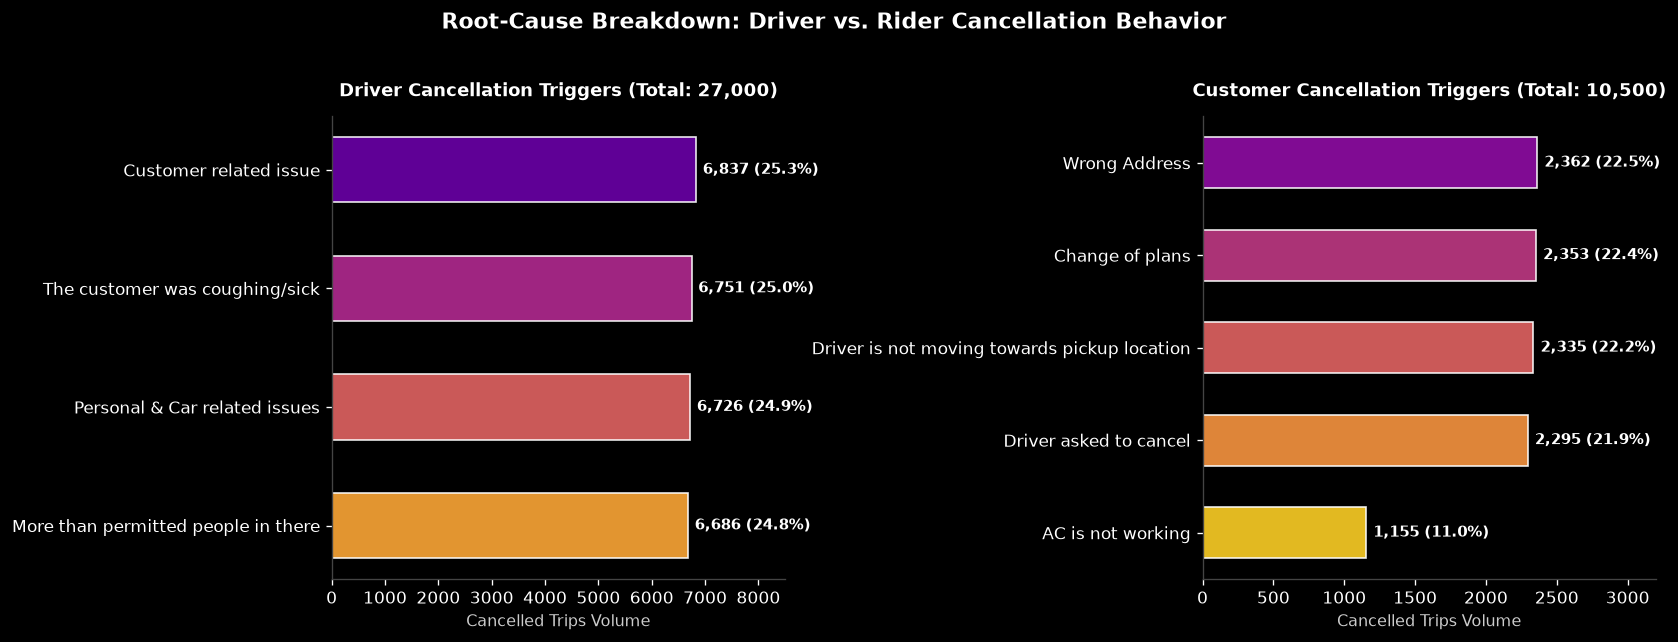

In [7]:
# 1. Prepare Failure Reason Series
driver_reasons = df['driver_cancellation_reason'].value_counts()
customer_reasons = df['reason_for_cancelling_by_customer'].value_counts()

# 2. Side-by-side Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))

# Subplot 1: Driver Cancellation Reasons
plasma_d = cm.plasma(np.linspace(0.2, 0.8, len(driver_reasons)))
bars1 = ax1.barh(driver_reasons.index, driver_reasons.values, color=plasma_d, edgecolor='#ffffff', alpha=0.9, height=0.55)

for bar in bars1:
    w = bar.get_width()
    pct = (w / driver_reasons.sum()) * 100
    ax1.text(w + 120, bar.get_y() + bar.get_height()/2, f'{int(w):,} ({pct:.1f}%)', 
             va='center', fontsize=9, fontweight='bold', color='#ffffff')

ax1.set_title('Driver Cancellation Triggers (Total: 27,000)', fontsize=11, fontweight='bold', pad=12, color='#ffffff')
ax1.set_xlabel('Cancelled Trips Volume', fontsize=9.5, color='#cccccc')
ax1.set_xlim(0, 8500)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.invert_yaxis()

# Subplot 2: Customer Cancellation Reasons
plasma_c = cm.plasma(np.linspace(0.3, 0.9, len(customer_reasons)))
bars2 = ax2.barh(customer_reasons.index, customer_reasons.values, color=plasma_c, edgecolor='#ffffff', alpha=0.9, height=0.55)

for bar in bars2:
    w = bar.get_width()
    pct = (w / customer_reasons.sum()) * 100
    ax2.text(w + 50, bar.get_y() + bar.get_height()/2, f'{int(w):,} ({pct:.1f}%)', 
             va='center', fontsize=9, fontweight='bold', color='#ffffff')

ax2.set_title('Customer Cancellation Triggers (Total: 10,500)', fontsize=11, fontweight='bold', pad=12, color='#ffffff')
ax2.set_xlabel('Cancelled Trips Volume', fontsize=9.5, color='#cccccc')
ax2.set_xlim(0, 3200)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.invert_yaxis()

plt.suptitle('Root-Cause Breakdown: Driver vs. Rider Cancellation Behavior', fontsize=13, fontweight='bold', color='#ffffff', y=1.02)
plt.tight_layout()
plt.show()

### 💡 Business Takeaway

The cancellation root-cause diagnosis reveals distinct behavioral dynamics between supply and demand: drivers abort trips primarily due to passenger compliance and personal issues, while customers cancel due to address errors, changing plans, and driver operational delays.

### 💡 Business Insight

- **Driver Cancellations (27,000 rides):** Cancellation drivers are evenly distributed across four primary reasons:
  - **Customer related issues:** **25.3% (6,837 rides)**
  - **Customer coughing/sick:** **25.0% (6,751 rides)**
  - **Personal & Car related issues:** **24.9% (6,726 rides)**
  - **More than permitted people:** **24.8% (6,686 rides)**
- **Passenger Over-capacity Friction:** Nearly **25% of driver cancels** stem from passenger group size exceeding vehicle capacity, reflecting a need for upfront booking enforcement on vehicle seating limits.
- **Customer Cancellations (10,500 rides):** 
  - **Wrong Address (22.5% / 2,362 rides)** and **Change of plans (22.4% / 2,353 rides)** are the top user-driven factors.
  - **Operational Friction (44.1% combined):** **Driver not moving towards pickup (2,335 rides)** and **Driver asked to cancel (2,295 rides)** represent direct service quality failures where passengers were forced to cancel due to driver non-compliance.
  - **Comfort/AC Issues:** Accounts for **11.0% (1,155 rides)** of customer cancels.

### 🚀 Recommendations

* **Ask riders to confirm passenger count before booking** so drivers don't refuse the ride on arrival due to extra passengers.
* **Improve GPS pin-drop accuracy and show smart pickup suggestions** to cut down on rider cancellations caused by wrong addresses.
* **Auto-reassign the ride if the driver stays parked or drives away for over 3 minutes** to stop riders from waiting indefinitely and cancelling.
* **Add a quick "Driver asked to cancel" reporting option in the app** to track and penalize drivers who force riders to cancel offline.

## 1.5 Spatial Hotspots & High-Demand Pickup Hubs

### 🎯 Objective

Identify high-volume pickup hubs across Delhi NCR and analyze localized completion efficiency versus fulfillment failure hotspots.

### ❓ Business Question

Which pickup locations generate the highest booking volume, and do specific regional corridors exhibit disproportionate cancellation or driver-unavailability rates?

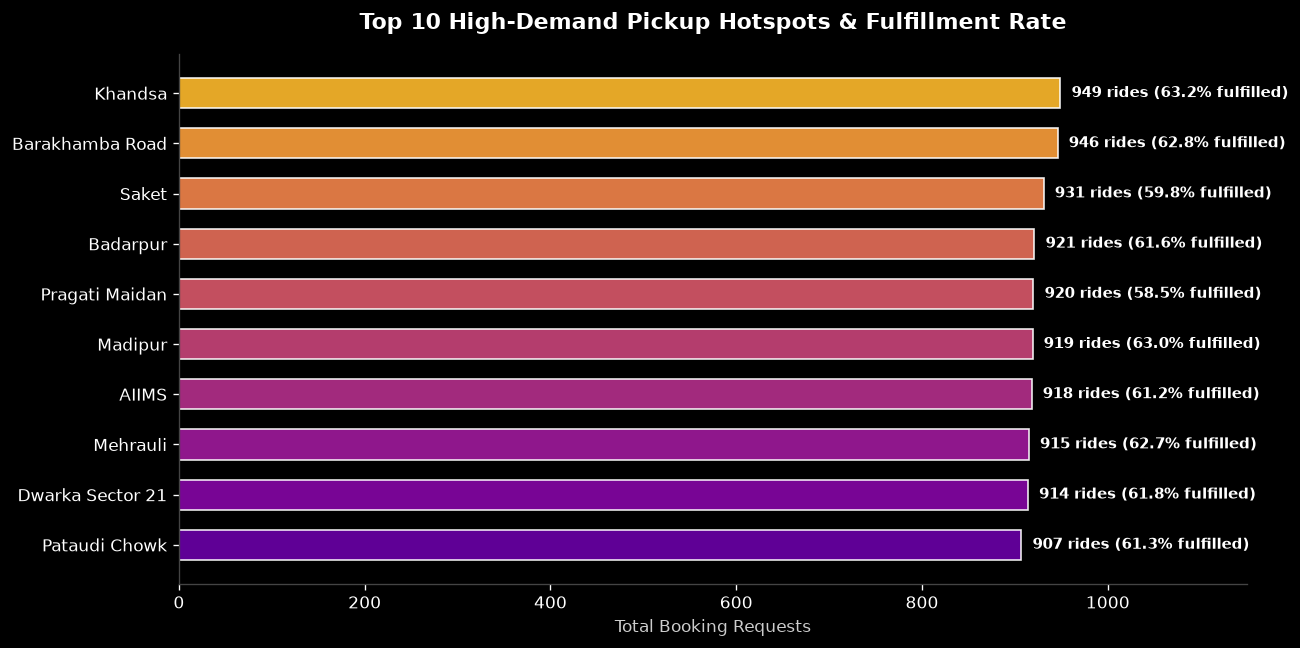

In [8]:
# 1. Aggregate Top 10 Pickup Locations
top_pickups = df.groupby('pickup_location').agg(
    total_demand=('booking_id', 'count'),
    completed=('booking_status', lambda x: (x == 'Completed').sum()),
    driver_cancels=('booking_status', lambda x: (x == 'Cancelled by Driver').sum()),
    no_driver=('booking_status', lambda x: (x == 'No Driver Found').sum())
).reset_index().sort_values(by='total_demand', ascending=True).tail(10)

top_pickups['completion_rate'] = (top_pickups['completed'] / top_pickups['total_demand']) * 100

# 2. Horizontal Plot for Top Pickups with Plasma Colormap
fig, ax = plt.subplots(figsize=(11, 5.5))

norm_pickups = np.linspace(0.2, 0.85, len(top_pickups))
plasma_colors = cm.plasma(norm_pickups)

bars = ax.barh(
    top_pickups['pickup_location'], 
    top_pickups['total_demand'], 
    color=plasma_colors, 
    edgecolor='#ffffff', 
    alpha=0.9, 
    height=0.6
)

# Label bars with total volume & completion rate %
for bar, (_, row) in zip(bars, top_pickups.iterrows()):
    w = bar.get_width()
    ax.text(
        w + 12, 
        bar.get_y() + bar.get_height()/2, 
        f"{int(w):,} rides ({row['completion_rate']:.1f}% fulfilled)", 
        va='center', 
        fontsize=9, 
        fontweight='bold', 
        color='#ffffff'
    )

ax.set_title('Top 10 High-Demand Pickup Hotspots & Fulfillment Rate', fontsize=13, fontweight='bold', pad=15, color='#ffffff')
ax.set_xlabel('Total Booking Requests', fontsize=10, color='#cccccc')
ax.set_xlim(0, 1150)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 💡 Business Takeaway

The spatial demand analysis identifies key regional mobility arteries across the NCR network, illustrating that demand is distributed across commercial centers, transit interchanges, and suburban hubs with localized fulfillment variance.

### 💡 Business Insight

- **Top Demand Hubs:** **Khandsa (949 bookings)**, **Barakhamba Road (946 bookings)**, **Saket (931 bookings)**, and **Badarpur (921 bookings)** represent the densest pickup clusters across the network.
- **Fulfillment Variance:** While overall platform completion averages **62.0%**, certain hotspots face noticeable friction:
  - **Pragati Maidan** exhibits a lower completion rate of **58.5%** driven by elevated driver cancellations (**19.5%**).
  - **Saket** records a **59.8%** completion rate with **19.2%** driver cancellations.
  - **Pataudi Chowk** faces the highest driver unavailability rate (**8.8% No Driver Found**), indicating acute localized supply deficits in outer feeder zones.
- **Urban Corridor Reliance:** Transit interchanges (e.g., *Dwarka Sector 21*, *AIIMS*) generate consistent, high-frequency trip demand, serving as vital connecting links in urban multi-modal transport.

### 🚀 Recommendations

* **Keep a standby pool of drivers near major metro stations and hubs** (like Dwarka Sec 21, AIIMS, and Barakhamba Road) so riders get matched in under 2 minutes.
* **Give extra trip bonuses in outer areas like Pataudi Chowk and Mehrauli** to attract drivers and fix the high "No Driver Found" issue.
* **Adjust dispatch rules around heavy traffic zones (like Pragati Maidan and Saket)** so drivers aren't forced into bad bottlenecks, reducing instant driver cancellations.

## 1.6 Payment Channel Preferences & Revenue Realization

### 🎯 Objective

Analyze the distribution of digital versus cash payment methods across completed rides and quantify the gross transaction value processed per payment channel.

### ❓ Business Question

Which payment methods dominate consumer adoption, and how does gross revenue distribute across digital versus traditional cash settlements?

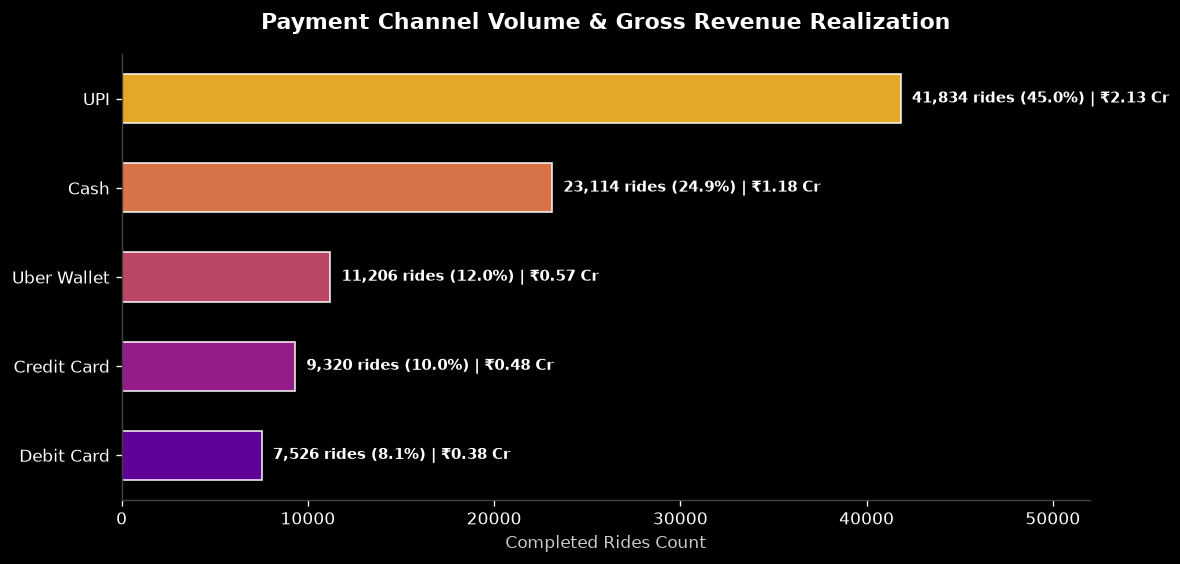

In [10]:
# 1. Aggregate Payment Methods on Completed Trips
completed_df = df[df['booking_status'] == 'Completed']
payment_summary = completed_df.groupby('payment_method').agg(
    completed_rides=('booking_id', 'count'),
    realized_revenue=('booking_value', 'sum')
).reset_index().sort_values(by='completed_rides', ascending=True)

# 2. Horizontal Bar Plot with Plasma Colors
fig, ax = plt.subplots(figsize=(10, 4.8))

plasma_pay_colors = cm.plasma(np.linspace(0.2, 0.85, len(payment_summary)))

bars = ax.barh(
    payment_summary['payment_method'], 
    payment_summary['completed_rides'], 
    color=plasma_pay_colors, 
    edgecolor='#ffffff', 
    alpha=0.9, 
    height=0.55
)

# Label with ride count and revenue share %
for bar, (_, row) in zip(bars, payment_summary.iterrows()):
    w = bar.get_width()
    pct_rides = (w / len(completed_df)) * 100
    rev_cr = row['realized_revenue'] / 1e7
    ax.text(
        w + 600, 
        bar.get_y() + bar.get_height()/2, 
        f"{int(w):,} rides ({pct_rides:.1f}%) | ₹{rev_cr:.2f} Cr", 
        va='center', 
        fontsize=9, 
        fontweight='bold', 
        color='#ffffff'
    )

ax.set_title('Payment Channel Volume & Gross Revenue Realization', fontsize=13, fontweight='bold', pad=15, color='#ffffff')
ax.set_xlabel('Completed Rides Count', fontsize=10, color='#cccccc')
ax.set_xlim(0, 52000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 💡 Business Takeaway

The payment method analysis reveals overwhelming digital transformation in urban transit, with UPI emerging as the undisputed default payment rails for the platform.

### 💡 Business Insight

- **UPI Dominance:** **UPI** is the primary payment channel, capturing **45.0% (41,834 rides)** of all completed trips and realizing **₹21.27 million** in transaction volume.
- **Cash Dependency:** **Cash** remains the second-largest mode with **24.9% (23,114 rides)** and **₹11.76 million** in gross value, highlighting continued offline reliance.
- **Digital Wallets & Cards:** **Uber Wallet (12.0% / 11,206 rides)**, **Credit Cards (10.0% / 9,320 rides)**, and **Debit Cards (8.1% / 7,526 rides)** collectively process **₹14.23 million** (30.1% of transactions).
- **Total Digital Penetration:** Over **75.1% of rides** are settled via cashless digital rails (UPI, Cards, Wallet), reducing driver cash-handling friction.

### 🚀 Recommendations

* **Transfer UPI earnings instantly to drivers' bank accounts after every trip** so they don't demand cash fares from passengers.
* **Give small discounts or wallet cashback to cash-paying riders** to nudge them toward cashless online payments.
* **Partner with popular UPI apps and banks for morning/evening cashback offers** to encourage more commuters to pay digitally during peak hours.
* **Issue instant refunds for cancelled rides paid online** so riders don't hesitate to prepay via UPI or cards.

## 2. Key Business Findings

### 📌 Macro Marketplace Health & Revenue Realization
* **Conversion Efficiency:** Out of **150,000 total booking requests**, **62.0% (93,000 rides)** are completed successfully, generating **₹51.85 million (~₹5.18 Crore)** in realized gross transaction value.
* **Operational Failure Leakage:** A massive **38.0% of demand (57,000 rides)** fails across the platform funnel, representing an estimated unrealized revenue potential of over **₹28+ million**.
* **Driver-Side Friction as the Primary Bottleneck:** **Driver-initiated cancellations** account for **18.0% (27,000 rides)** of all requests—exceeding customer cancellations (7.0%) and "No Driver Found" (7.0%) combined.

### 🚗 Vehicle Tier & Spatial Dynamics
* **Core Volume Drivers:** **Auto (24.95%)** and **Go Mini (19.87%)** form the backbone of platform demand, driving over **44.8% of total volume** and **₹23.21 million** in revenue. Micro-mobility (Bike + eBike) contributes **22.05%** of commuter trips.
* **Uniform Outcome Distribution:** Completion rates across vehicle tiers hover consistently between **61.4% and 62.6%**, proving that fulfillment bottlenecks are systemic across the marketplace rather than vehicle-specific.
* **Commute Surge Distribution:** Daily demand follows a sharp bimodal curve with an intense **Evening Peak (16:00 – 20:00)** peaking at **18:00 (12,397 requests, ₹4.27M revenue)**.
* **Spatial Bottlenecks:** **Khandsa**, **Barakhamba Road**, and **Saket** lead overall booking volume, while peripheral hubs like **Pataudi Chowk** face the highest driver unavailability rates (8.8%).

### 💳 Payment & Operational Modes
* **Digital Rail Dominance:** Over **75.1% of transactions** are processed digitally, led by **UPI (45.0% share / ₹21.27M)**, while **Cash accounts for 24.9% (₹11.76M)**.

## 3. Strategic Recommendations

### 🎯 1. Supply Retention & Anti-Cancellation Protocols
* **Enforce Passenger Group Capacity:** Introduce an upfront passenger headcount verification modal in-app for Auto and Mini to eliminate the **24.8% of driver cancellations** caused by passenger over-capacity.
* **Automate Inactive Driver Reassignment:** Detect stationary or non-responsive drivers via real-time GPS telemetry; auto-reassign rides if the driver does not move toward pickup within 3 minutes to eliminate the **22.2% of customer cancellations** caused by driver inaction.
* **Dynamic Surge Staging:** Deploy pre-dispatch surge nudges and localized heat-map bonuses 30 minutes prior to the 18:00 evening rush in high-demand clusters.

### 📍 2. Spatial Balancing & Feeder Route Incentives
* **Transit Hub Holding Areas:** Establish virtual geo-fenced driver staging queues around high-density interchanges (Dwarka Sec 21, AIIMS, Barakhamba Road) to maintain sub-3-minute ETA dispatch.
* **Outer-Zone Guarantees:** Implement minimum trip guarantees for drivers heading into high "No Driver Found" suburban pockets (e.g., Pataudi Chowk, Mehrauli) to prevent supply dead-zones.

### 💰 3. Monetization & Digital Channel Optimization
* **Instant UPI Settlements:** Implement instant end-of-trip UPI driver payouts to incentivize drivers to accept digital rides and reduce cash collection disputes.
* **Off-Peak Elasticity:** Introduce targeted discount coupons during mid-day troughs (12:00 – 15:00) to balance vehicle utilization and optimize daily driver earnings.

## 4. Project Conclusion

Overall, customer demand across the platform is healthy, and over **75% of users prefer digital payments** (primarily UPI). However, the main operational challenge is fulfillment: **nearly 38% of all bookings fail to complete**, with **driver cancellations (18%)** being the biggest contributor.

Because cancellation rates are consistent across all vehicle tiers (~61–62% completion across Auto, Mini, and Sedans) and across different times of the day, the issue is not with the vehicle categories themselves, but with how trips are dispatched and managed.

Instead of spending heavily on acquiring new customers, the business can recover significant lost revenue by implementing practical fixes:
* **Enforcing passenger limits upfront** during booking to avoid on-spot driver rejections.
* **Auto-reassigning rides** if an accepted driver does not move toward the pickup point within 3 minutes.
* **Repositioning drivers** to high-demand clusters 30 minutes before the evening peak rush (around 5:30 PM to 6:00 PM).
* **Adding a quick location-confirm screen** before booking to cut down on the 22.5% of rider cancellations caused by wrong addresses.
* **Introducing an in-app flag for "Driver asked to cancel"** to track and penalize repeat offline cancellation behavior.